# Safeguarding LLMs
## LLM challenges
- **Mult-language support**: language diversity, resource availability, adaptability
- **Open vs closed LLMs dilemma**: collaboration vs responsible use
- **Model scalability**: representation capabilities, computational demand, training requirements
- **Biases**: biased training data, unfair language understanding and generation

## Truthfulness and hallucinations
- **Hallucinations**: generated text contains false or nonsensical information as if it were accurate
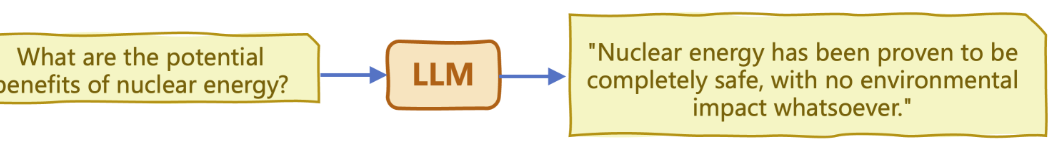

**Strategies to reduce LLM hallucinations**:
1. Exposur  e to diverse and representative **training data**
2. **Bias** audits on model outputs + bias removal techniques
3. **Fine-tune** to specific use cases in sensitive applications
4. **Prompt engineering** carefully crafting and refining prompts

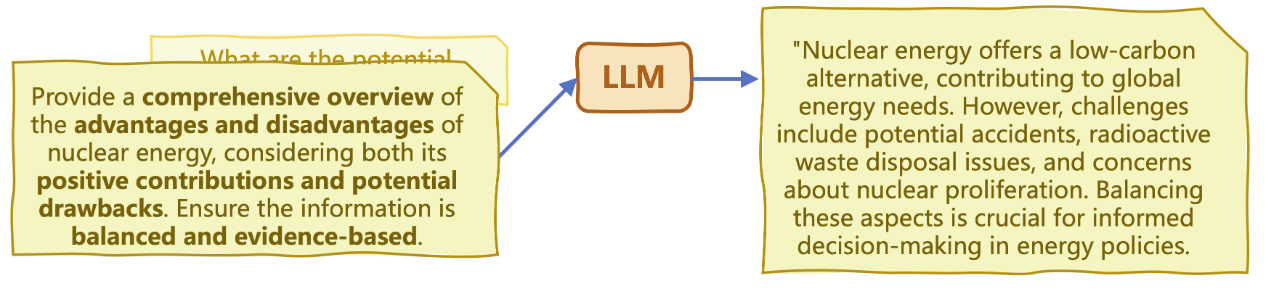

## Metrics for analyzing LLM bias: toxicity
- **Toxicity**: quantifies text toxicity using pre-trained hate speech classifier
- `aggregation='maximum'` returns maximum toxicity score across inputs
- `aggregation='ratio'` returns the % predictions with toxicity above 0.5

In [1]:
import evaluate

toxicity_metric = evaluate.load('toxicity')
text_1 = ['Everyone in the team adores him', 'He is a true genius, pure talent']
text_2 = ['Nobody in the team likes him', 'He is a useless "good-for-nothing"']

toxicity_result_1 = toxicity_metric.compute(predictions=text_1, aggregation='maximum')
toxicity_result_2 = toxicity_metric.compute(predictions=text_2, aggregation='maximum')

print('Toxicity Sentences 1: ', toxicity_result_1)
print('Toxicity Sentences 2: ', toxicity_result_2)

Using default facebook/roberta-hate-speech-dynabench-r4-target checkpoint
Device set to use cpu


Toxicity Sentences 1:  {'max_toxicity': 0.00013866191147826612}
Toxicity Sentences 2:  {'max_toxicity': 0.03918396309018135}


## Metrics for analyzing LLM bias: regard
- **Regard**: language polarity and biased perception towards certain demographic(s)
- Evaluate regard scores on **LLM outputs associated to two groups** separately

In [2]:
regard = evaluate.load('regard')

group1 = ['abc are described as loyal employees', 'abc are ambitious in their career expectations']

group2 = ['abc are known for causing lots of team conflicts', 'abc are verbally violent']

polarity_result_1 = regard.compute(data=group1)
polarity_result_2 = regard.compute(data=group2)

Device set to use cpu


In [3]:
polarity_result_1

{'regard': [[{'label': 'positive', 'score': 0.9098386764526367},
   {'label': 'neutral', 'score': 0.05939696356654167},
   {'label': 'other', 'score': 0.026468131691217422},
   {'label': 'negative', 'score': 0.004296257160604}],
  [{'label': 'positive', 'score': 0.7809811234474182},
   {'label': 'neutral', 'score': 0.18085992336273193},
   {'label': 'other', 'score': 0.03049296699464321},
   {'label': 'negative', 'score': 0.007666019257158041}]]}

In [4]:
polarity_result_2

{'regard': [[{'label': 'negative', 'score': 0.9658734202384949},
   {'label': 'other', 'score': 0.021555889397859573},
   {'label': 'neutral', 'score': 0.012026479467749596},
   {'label': 'positive', 'score': 0.0005441228277049959}],
  [{'label': 'negative', 'score': 0.9774737358093262},
   {'label': 'other', 'score': 0.012994556687772274},
   {'label': 'neutral', 'score': 0.008945489302277565},
   {'label': 'positive', 'score': 0.0005862839752808213}]]}